<a href="https://colab.research.google.com/github/apHub27/sveltetech-ai-internship/blob/main/imageClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 Downloading real handwritten digit images (MNIST)...
✅ Successfully loaded 60000 real images!
🖼️ Displaying the first image. The correct label is: 3


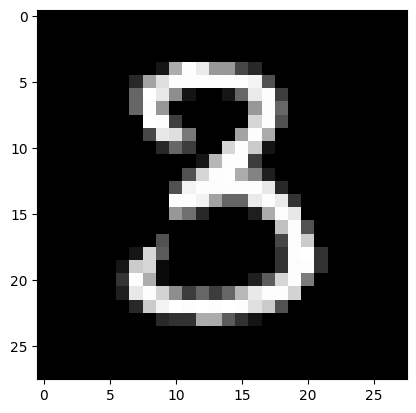


🚀 Training the network on real images...
🏅 Epoch [1/3] | Loss: 0.3803
🏅 Epoch [2/3] | Loss: 0.1839
🏅 Epoch [3/3] | Loss: 0.1369

🔮 Testing model on image index 5...


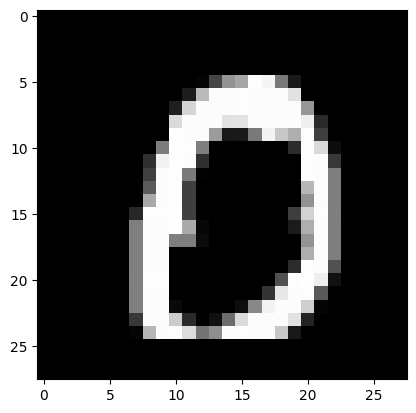

True Handwritten Label: 0
🎉 Model's Predicted Guess: 0


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: DOWNLOAD ACTUAL IMAGES
# ==========================================
print("📥 Downloading real handwritten digit images (MNIST)...")

# Transform converts the images into PyTorch Tensors automatically
transform = transforms.Compose([transforms.ToTensor()])

# Download the real training dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Put them into a DataLoader (Batch Size = 64)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"✅ Successfully loaded {len(train_dataset)} real images!")


# ==========================================
# STEP 2: SEE A REAL IMAGE FROM THE DATASET
# ==========================================
# Let's pull out one real image to look at it
images, labels = next(iter(train_loader))

print(f"🖼️ Displaying the first image. The correct label is: {labels[0].item()}")
plt.imshow(images[0].squeeze(), cmap='gray')
plt.show()  # This will pop up a real picture of a handwritten number!


# ==========================================
# STEP 3: DEFINE THE NEURAL NETWORK
# ==========================================
class ImageClassifier(nn.Module):
    def __init__(self):
        super(ImageClassifier, self).__init__()

        # Real images are 28x28 pixels = 784 total input numbers
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

        # Output layer has 10 outputs (for numbers 0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Because our image is a 2D grid (28x28), we must flatten it into a 1D line (784)
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImageClassifier()


# ==========================================
# STEP 4: LOSS FUNCTION & OPTIMIZER
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ==========================================
# STEP 5: THE TRAINING LOOP
# ==========================================
print("\n🚀 Training the network on real images...")
epochs = 3  # 3 epochs is enough to get great accuracy on this dataset

for epoch in range(epochs):
    running_loss = 0.0

    for batch_images, batch_labels in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_images)  # Pass the real images forward
        loss = criterion(outputs, batch_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"🏅 Epoch [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader):.4f}")


# ==========================================
# STEP 6: TEST PREDICTION ON A REAL IMAGE
# ==========================================
model.eval()
with torch.no_grad():
    # Pick a random image from our batch to test
    test_img = images[5]
    true_ans = labels[5].item()

    # Get model's guess
    raw_output = model(test_img)
    probabilities = torch.softmax(raw_output, dim=1)
    predicted_ans = torch.argmax(probabilities).item()

    # Show the image we tested
    print(f"\n🔮 Testing model on image index 5...")
    plt.imshow(test_img.squeeze(), cmap='gray')
    plt.show()

    print(f"True Handwritten Label: {true_ans}")
    print(f"🎉 Model's Predicted Guess: {predicted_ans}")
